# Theme 11: 교차 검증 (2026-04-29)

## 1. 환경 설정

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    RandomizedSearchCV,
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    r2_score,
    mean_absolute_error,
    accuracy_score,
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from scipy.stats import randint

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "NanumGothic"  # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams["axes.unicode_minus"] = False

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        84
           1       0.91      0.88      0.89        66

    accuracy                           0.91       150
   macro avg       0.91      0.90      0.90       150
weighted avg       0.91      0.91      0.91       150



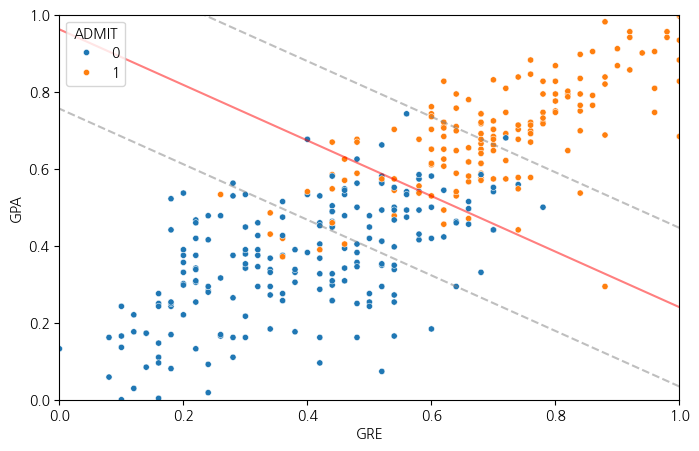

In [ ]:
df = pd.read_csv("content/admission_simple.csv")

target = "ADMIT"
X = df[["GRE", "GPA"]]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=1
)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel="linear", C=1, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

xx = np.linspace(0, 1, 30)  # x 축에 해당하는 값
yy = np.linspace(0, 1, 30)  # y 축에 해당하는 값
yy, xx = np.meshgrid(yy, xx)
xy = np.vstack([xx.ravel(), yy.ravel()]).T  # 그리드의 좌표를 벡터 형태로 변환
z = model.decision_function(xy).reshape(
    xx.shape
)  # SVM 모델이 각 좌표(x,y)에 대해 결정 함수 값을 계산

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, s=20)

# 결정 경계
plt.contour(
    xx,
    yy,
    z,
    levels=[-1, 0, 1],  # 서포트 벡터 경계
    alpha=0.5,  # 투명도
    colors=["gray", "red", "gray"],
    linestyles=["--", "-", "--"],
)

plt.xlabel("GRE")
plt.ylabel("GPA")
plt.show()

In [ ]:
mobile = pd.read_csv("content/mobile_cust_churn.csv")

dummies = [
    "REPORTED_SATISFACTION",
    "REPORTED_USAGE_LEVEL",
    "CONSIDERING_CHANGE_OF_PLAN",
]

mobile.drop(["id", "COLLEGE"], axis=1, inplace=True)

target = "CHURN"

X = pd.get_dummies(data=mobile.drop(target, axis=1), columns=dummies, drop_first=True)
y = mobile[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=1
)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

best_model = SVC(
    kernel="rbf",
    C=10,
    gamma=0.1,
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       LEAVE       0.67      0.60      0.63      2935
        STAY       0.65      0.72      0.68      3065

    accuracy                           0.66      6000
   macro avg       0.66      0.66      0.66      6000
weighted avg       0.66      0.66      0.66      6000



In [ ]:
boston = pd.read_csv("content/boston.csv")

target = "medv"

X = boston.drop(target, axis=1)
y = boston[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=1
)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

model = SVR(kernel="rbf", C=10, gamma=1, epsilon=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

R2 Score: 0.8414
MAE: 2.5136


In [ ]:
def k_fold_c(X_train, y_train, X_train_scaled):
    model_dt = DecisionTreeClassifier(max_depth=4)
    model_knn = KNeighborsClassifier(n_neighbors=3)
    model_lr = LogisticRegression()
    model_svm = SVC(C=1)
    cv_score_dt = cross_val_score(model_dt, X_train, y_train, cv=10, scoring="accuracy")
    cv_score_knn = cross_val_score(
        model_knn, X_train_scaled, y_train, cv=10, scoring="accuracy"
    )
    cv_score_lr = cross_val_score(model_lr, X_train, y_train, cv=10, scoring="accuracy")
    cv_score_svm = cross_val_score(
        model_svm, X_train, y_train, cv=10, scoring="accuracy"
    )

    for c in [cv_score_dt, cv_score_knn, cv_score_lr, cv_score_svm]:
        print([f"{i:0.2f}" for i in c])
        print(f"평균 : {c.mean():0.2f}")
        print(f"표준편차 : {c.std():0.5f}")


dia = pd.read_csv("content/diabetes.csv")

target = "Outcome"

X = dia.drop(target, axis=1)
y = dia[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=1
)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_fold_c(X_train, y_train, X_train_scaled)

['0.63', '0.72', '0.80', '0.70', '0.74', '0.74', '0.72', '0.77', '0.74', '0.70']
평균 : 0.73
표준편차 : 0.04281
['0.70', '0.65', '0.80', '0.72', '0.74', '0.81', '0.57', '0.62', '0.75', '0.62']
평균 : 0.70
표준편차 : 0.07624
['0.70', '0.72', '0.85', '0.74', '0.83', '0.81', '0.74', '0.75', '0.77', '0.75']
평균 : 0.77
표준편차 : 0.04645
['0.67', '0.76', '0.80', '0.74', '0.80', '0.76', '0.67', '0.79', '0.77', '0.74']
평균 : 0.75
표준편차 : 0.04580


In [ ]:
def k_fold_r(X_train, y_train, X_train_scaled):
    model_dt = DecisionTreeRegressor(max_depth=4)
    model_knn = KNeighborsRegressor(n_neighbors=4)
    model_lr = LinearRegression()
    model_svm = SVR(C=10, kernel="rbf", gamma=1)
    cv_score_dt = cross_val_score(model_dt, X_train, y_train, cv=10, scoring="r2")
    cv_score_knn = cross_val_score(
        model_knn, X_train_scaled, y_train, cv=10, scoring="r2"
    )
    cv_score_lr = cross_val_score(model_lr, X_train, y_train, cv=10, scoring="r2")
    cv_score_svm = cross_val_score(
        model_svm, X_train_scaled, y_train, cv=10, scoring="r2"
    )

    for c in [cv_score_dt, cv_score_knn, cv_score_lr, cv_score_svm]:
        print([f"{i:0.2f}" for i in c])
        print(f"평균 : {c.mean():0.2f}")
        print(f"표준편차 : {c.std():0.5f}")


target = "medv"

X = boston.drop(target, axis=1)
y = boston[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=1
)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_fold_r(X_train, y_train, X_train_scaled)

['0.69', '0.70', '0.90', '0.75', '0.79', '0.82', '0.67', '0.82', '0.85', '0.88']
평균 : 0.79
표준편차 : 0.07717
['0.68', '0.60', '0.72', '0.59', '0.75', '0.71', '0.62', '0.69', '0.43', '0.86']
평균 : 0.67
표준편차 : 0.10995
['0.60', '0.45', '0.82', '0.65', '0.76', '0.57', '0.67', '0.77', '0.56', '0.84']
평균 : 0.67
표준편차 : 0.12069
['0.78', '0.58', '0.76', '0.82', '0.89', '0.72', '0.73', '0.80', '0.63', '0.93']
평균 : 0.76
표준편차 : 0.10182


In [ ]:
target = "CHURN"

X = pd.get_dummies(data=mobile.drop(target, axis=1), columns=dummies, drop_first=True)
y = mobile[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=1
)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_fold_c(X_train, y_train, X_train_scaled)

['0.70', '0.69', '0.72', '0.69', '0.70', '0.71', '0.71', '0.69', '0.70', '0.69']
평균 : 0.70
표준편차 : 0.00995
['0.61', '0.62', '0.60', '0.60', '0.62', '0.60', '0.60', '0.58', '0.60', '0.60']
평균 : 0.60
표준편차 : 0.01065
['0.62', '0.63', '0.63', '0.64', '0.63', '0.63', '0.65', '0.64', '0.65', '0.62']
평균 : 0.63
표준편차 : 0.01147
['0.63', '0.61', '0.63', '0.61', '0.61', '0.62', '0.62', '0.61', '0.61', '0.62']
평균 : 0.62
표준편차 : 0.00603


In [ ]:
target = "medv"

X = boston.drop(target, axis=1)
y = boston[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=1
)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_dt = DecisionTreeRegressor(max_depth=5)

param_grid = {
    "max_depth": range(2, 6),
}
# 2. GridSearchCV 객체 생성 (회귀이므로 scoring은 보통 'r2'나 'neg_mean_absolute_error' 사용)
grid_dt = GridSearchCV(model_dt, param_grid, cv=5, scoring="r2")
# 3. 학습
grid_dt.fit(X_train, y_train)
# 4. 결과 확인
print(f"최적의 파라미터: {grid_dt.best_params_}")
print(f"최고 R2 Score: {grid_dt.best_score_:.4f}")
# 5. 최적 모델로 최종 예측 및 평가
best_svr = grid_dt.best_estimator_
y_pred = best_svr.predict(X_test)
print(f"최종 R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"최종 MAE: {mean_absolute_error(y_test, y_pred):.4f}")

최적의 파라미터: {'max_depth': 5}
최고 R2 Score: 0.7453
최종 R2 Score: 0.8475
최종 MAE: 2.7922


최적의 파라미터: {'max_depth': 4}
최고 accuracy: 0.6994
최종 accuracy: 0.7033
최종 classification_report:
              precision    recall  f1-score   support

       LEAVE       0.67      0.78      0.72      2935
        STAY       0.75      0.63      0.68      3065

    accuracy                           0.70      6000
   macro avg       0.71      0.70      0.70      6000
weighted avg       0.71      0.70      0.70      6000



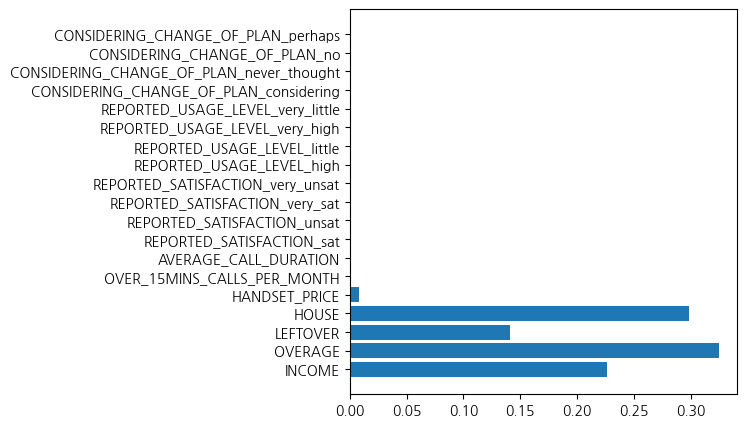

In [ ]:
target = "CHURN"

X = pd.get_dummies(data=mobile.drop(target, axis=1), columns=dummies, drop_first=True)
y = mobile[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=1
)

model_dt = DecisionTreeClassifier(max_depth=5)

param_grid = {
    "max_depth": range(2, 11),
}
# 2. GridSearchCV 객체 생성
grid_dt = GridSearchCV(model_dt, param_grid, cv=5, scoring="accuracy")
# 3. 학습
grid_dt.fit(X_train, y_train)
# 4. 결과 확인
print(f"최적의 파라미터: {grid_dt.best_params_}")
print(f"최고 accuracy: {grid_dt.best_score_:.4f}")
# 5. 최적 모델로 최종 예측 및 평가
best_svr = grid_dt.best_estimator_
y_pred = best_svr.predict(X_test)
print(f"최종 accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("최종 classification_report:")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(5, 5))
plt.barh(y=list(X), width=grid_dt.best_estimator_.feature_importances_)
plt.show()

최적의 파라미터: {'max_depth': 8}
최고 R2 Score: 0.7621
최종 R2 Score: 0.8335
최종 MAE: 2.7042


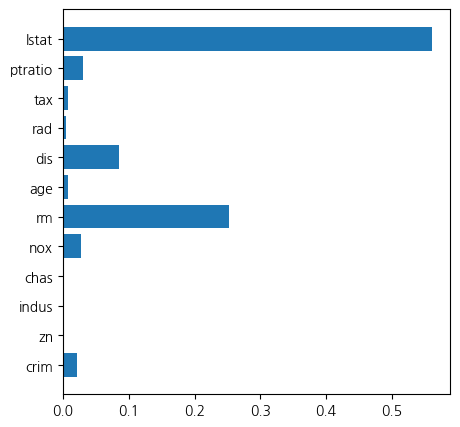

In [ ]:
target = "medv"

X = boston.drop(target, axis=1)
y = boston[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=1
)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_dt = DecisionTreeRegressor(max_depth=5)

param_dist = {
    "max_depth": randint(2, 8),
}

rand_dt = RandomizedSearchCV(model_dt, param_grid, n_iter=10, cv=5)
# 3. 학습
rand_dt.fit(X_train, y_train)
# 4. 결과 확인
print(f"최적의 파라미터: {rand_dt.best_params_}")
print(f"최고 R2 Score: {rand_dt.best_score_:.4f}")
# 5. 최적 모델로 최종 예측 및 평가
best_svr = rand_dt.best_estimator_
y_pred = best_svr.predict(X_test)
print(f"최종 R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"최종 MAE: {mean_absolute_error(y_test, y_pred):.4f}")
plt.figure(figsize=(5, 5))
plt.barh(y=list(X), width=rand_dt.best_estimator_.feature_importances_)
plt.show()

In [ ]:
target = "CHURN"

X = pd.get_dummies(data=mobile.drop(target, axis=1), columns=dummies, drop_first=True)
y = mobile[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=1
)

model_dt = KNeighborsClassifier()

param_grid = {
    "n_neighbors": range(2, 6),
}

rand_dt = RandomizedSearchCV(model_dt, param_grid, n_iter=10, cv=5)
# 3. 학습
rand_dt.fit(X_train, y_train)
# 4. 결과 확인
print(f"최적의 파라미터: {rand_dt.best_params_}")
print(f"최고 accuracy: {rand_dt.best_score_:.4f}")
# 5. 최적 모델로 최종 예측 및 평가
best_svr = rand_dt.best_estimator_
y_pred = best_svr.predict(X_test)
print(f"최종 accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("최종 classification_report:")
print(classification_report(y_test, y_pred))

최적의 파라미터: {'n_neighbors': 4}
최고 accuracy: 0.5892
최종 accuracy: 0.5735
최종 classification_report:
              precision    recall  f1-score   support

       LEAVE       0.55      0.73      0.63      2935
        STAY       0.62      0.42      0.50      3065

    accuracy                           0.57      6000
   macro avg       0.59      0.58      0.56      6000
weighted avg       0.59      0.57      0.56      6000

